In [1]:
# ============================================================
# CASE STUDY: HIDDEN WORKFORCE GROUP DISCOVERY
# UNSUPERVISED LEARNING - CLUSTERING
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score

from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import dendrogram, linkage

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
!pip install -q gdown

In [3]:
import gdown

file_id = "1DJEHSb5MnvdGnfWrvT5wZ_DnwOx-wxyx"

url = f"https://drive.google.com/uc?id={file_id}"

output_file = "census_data.csv"

gdown.download(
    url,
    output_file,
    quiet=False
)

print("Dataset downloaded successfully.")

Downloading...
From: https://drive.google.com/uc?id=1DJEHSb5MnvdGnfWrvT5wZ_DnwOx-wxyx
To: /content/census_data.csv
100%|██████████| 5.39M/5.39M [00:00<00:00, 26.5MB/s]

Dataset downloaded successfully.


In [4]:
df = pd.read_csv("census_data.csv")

print("Dataset loaded successfully.")

display(df.head())

Dataset loaded successfully.


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,NaN,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


In [5]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (48842, 15)

Column Names:
['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             46400 non-null  float64
 1   workclass       45480 non-null  object 
 2   fnlwgt          48842 non-null  int64  
 3   education       48842 non-null  object 
 4   education-num   48842 non-null  int64  
 5   marital-status  48842 non-null  object 
 6   occupation      45485 non-null  object 
 7   relationship    48842 non-null  object 
 8   race            48842 non-null  object 
 9   sex             48842 non-null  object 
 10  capital-gain    48842 non-null  int64  
 11  capital-loss    48842 non-null  int

In [6]:
df.columns = df.columns.str.strip()

print("Cleaned Column Names:")
print(df.columns.tolist())

Cleaned Column Names:
['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']


In [7]:
df.columns = df.columns.str.lower()

print(df.columns.tolist())

['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']


In [8]:
print("Number of duplicate rows:")
print(df.duplicated().sum())

Number of duplicate rows:
16


In [9]:
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (48826, 15)


In [12]:
categorical_columns_initial = df.select_dtypes(
    include=["object", "category"]
).columns

for column in categorical_columns_initial:
    df[column] = df[column].astype(str).str.strip()
    df.replace("?", np.nan, inplace=True)

print(" '?' values replaced with NaN.")

 '?' values replaced with NaN.


In [13]:
missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df)) * 100
})

display(
    missing_values[
        missing_values["Missing Values"] > 0
    ].sort_values(
        by="Missing Values",
        ascending=False
    )
)

,Missing Values,Percentage
age,2442,5.001434
hours-per-week,2442,5.001434
workclass,1763,3.610781


In [14]:
income_columns = [
    col for col in df.columns
    if col.lower() in ["income", "salary", "class"]
]

print("Possible income column:", income_columns)

Possible income column: ['income']


In [15]:
if "income" in df.columns:
    df = df.drop(columns=["income"])
    print("Income column successfully removed.")
else:
    print("Income column not found. Check column names.")

Income column successfully removed.


In [16]:
print(df.columns.tolist())

['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country']


In [17]:
numerical_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

Categorical Columns:
['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


In [18]:
for column in numerical_columns:

    if df[column].isnull().sum() > 0:

        median_value = df[column].median()

        df[column] = df[column].fillna(median_value)

        print(
            column,
            "filled with median:",
            median_value
        )

age filled with median: 37.0
hours-per-week filled with median: 40.0


In [19]:
for column in categorical_columns:

    if df[column].isnull().sum() > 0:

        mode_value = df[column].mode()[0]

        df[column] = df[column].fillna(mode_value)

        print(
            column,
            "filled with mode:",
            mode_value
        )

workclass filled with mode: Private


In [20]:
print("Total missing values after treatment:")

print(df.isnull().sum().sum())

Total missing values after treatment:
0


In [21]:
display(
    pd.DataFrame({
        "Missing Values": df.isnull().sum()
    })
)

,Missing Values
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [22]:
outlier_summary = []

for column in numerical_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    outlier_summary.append({
        "Feature": column,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Number of Outliers": len(outliers),
        "Percentage": len(outliers) / len(df) * 100
    })

outlier_df = pd.DataFrame(outlier_summary)

display(outlier_df)

,Feature,Lower Bound,Upper Bound,Number of Outliers,Percentage
0,age,-0.5,75.5,363,0.743456
1,fnlwgt,-62538.0,417710.0,1453,2.975874
2,education-num,4.5,16.5,1792,3.670176
3,capital-gain,0.0,0.0,4035,8.264040
4,capital-loss,0.0,0.0,2282,4.673739
5,hours-per-week,32.5,52.5,12833,26.283128


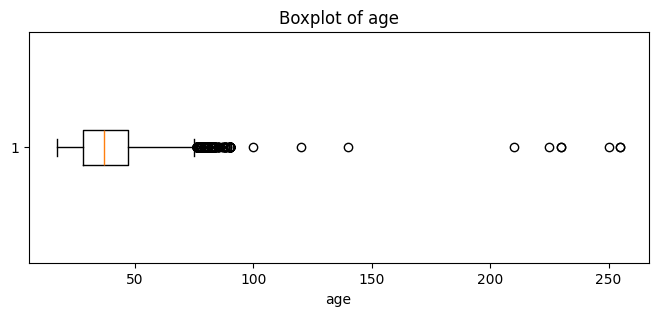

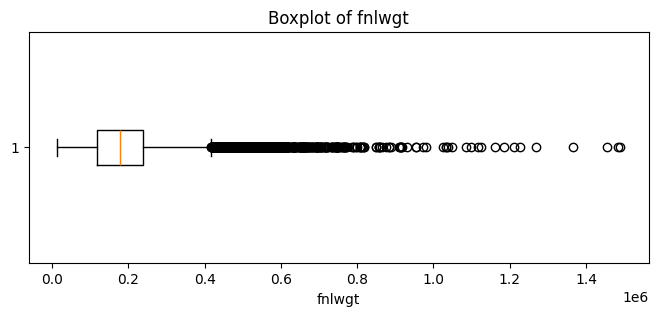

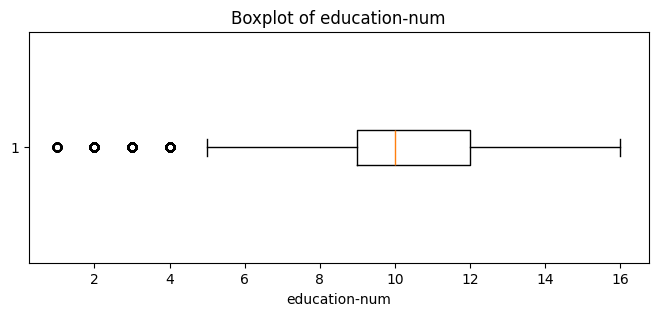

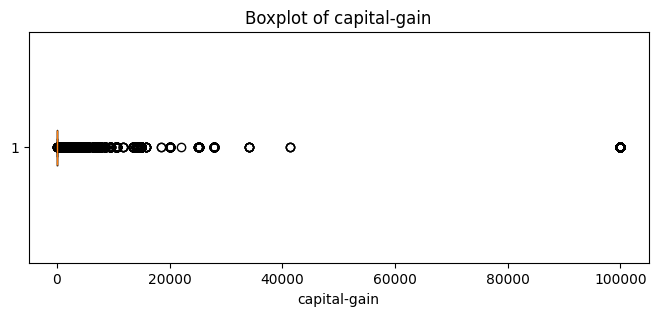

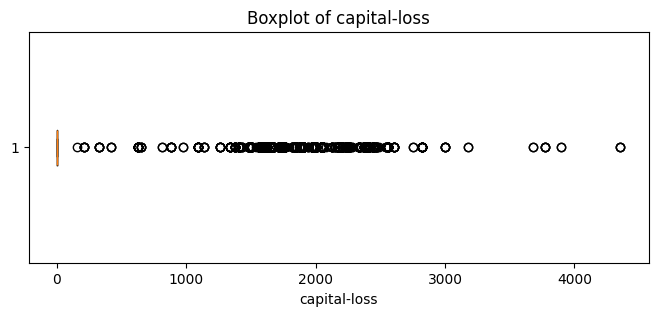

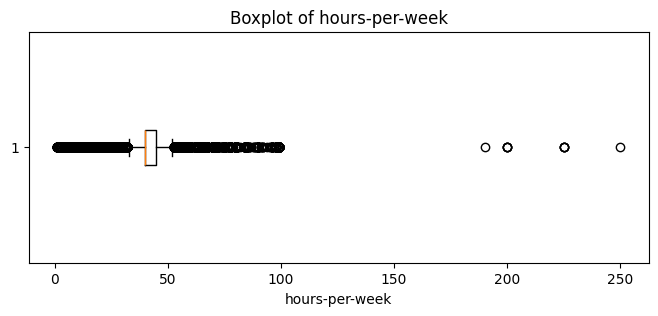

In [23]:
for column in numerical_columns:

    plt.figure(figsize=(8, 3))

    plt.boxplot(
        df[column].dropna(),
        vert=False
    )

    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)

    plt.show()

In [24]:
df_clean = df.copy()

for column in numerical_columns:

    Q1 = df_clean[column].quantile(0.25)
    Q3 = df_clean[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_clean[column] = df_clean[column].clip(
        lower=lower_bound,
        upper=upper_bound
    )

print("Outlier treatment completed.")

Outlier treatment completed.


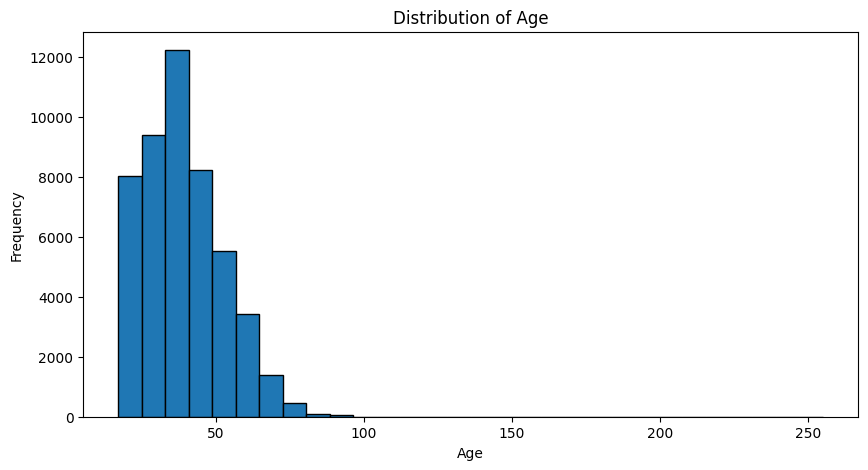

In [25]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["age"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

In [26]:
print("Age Statistics:")

display(
    df["age"].describe()
)

Age Statistics:


,age
count,48826.000000
mean,38.597428
std,13.602653
min,17.000000
25%,28.000000
50%,37.000000
75%,47.000000
max,255.000000


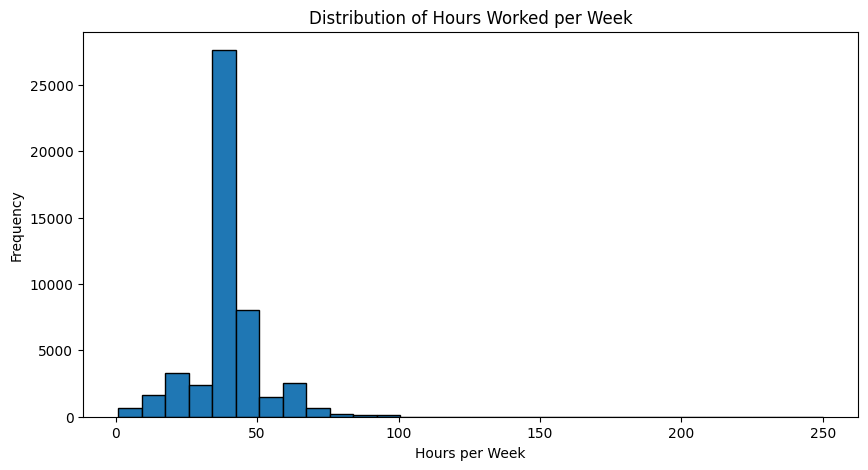

In [27]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["hours-per-week"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Hours Worked per Week")
plt.xlabel("Hours per Week")
plt.ylabel("Frequency")

plt.show()

In [28]:
display(
    df["hours-per-week"].describe()
)

,hours-per-week
count,48826.000000
mean,40.428481
std,12.326046
min,1.000000
25%,40.000000
50%,40.000000
75%,45.000000
max,250.000000


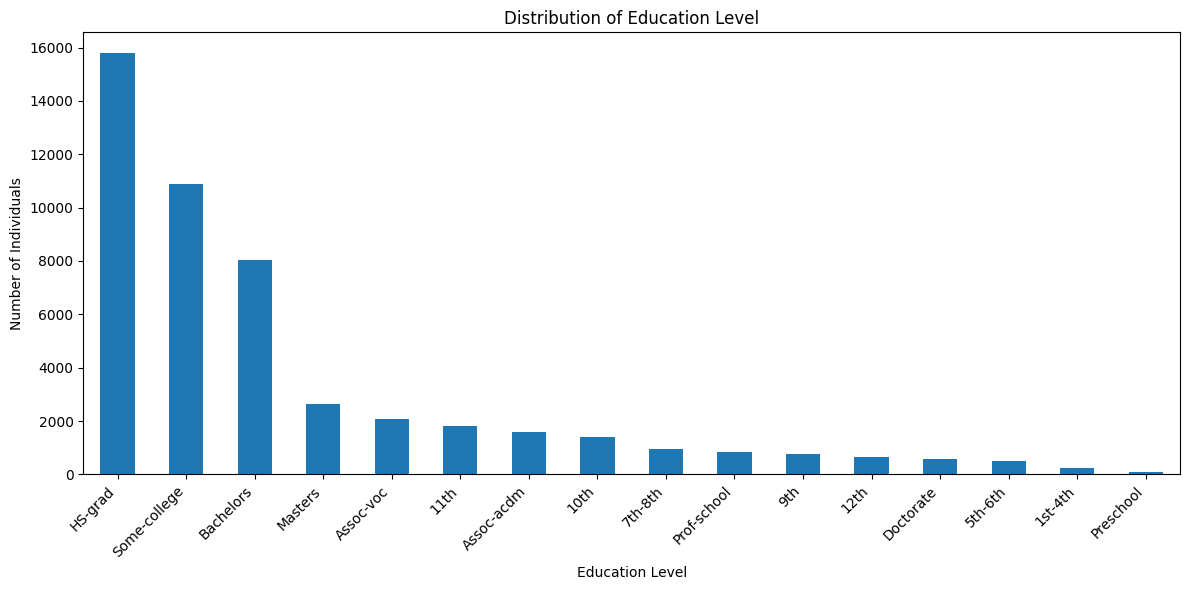

In [29]:
education_counts = df["education"].value_counts()

plt.figure(figsize=(12, 6))

education_counts.plot(
    kind="bar"
)

plt.title("Distribution of Education Level")
plt.xlabel("Education Level")
plt.ylabel("Number of Individuals")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()

In [30]:
display(
    education_counts.to_frame(
        name="Count"
    )
)

,Count
education,
HS-grad,15780
Some-college,10874
Bachelors,8021
Masters,2657
Assoc-voc,2060
11th,1812
Assoc-acdm,1601
10th,1389
7th-8th,955


In [31]:
capital_gain_skew = df["capital-gain"].skew()
capital_loss_skew = df["capital-loss"].skew()

print(
    "Capital Gain Skewness:",
    round(capital_gain_skew, 3)
)

print(
    "Capital Loss Skewness:",
    round(capital_loss_skew, 3)
)

Capital Gain Skewness: 11.893
Capital Loss Skewness: 4.569


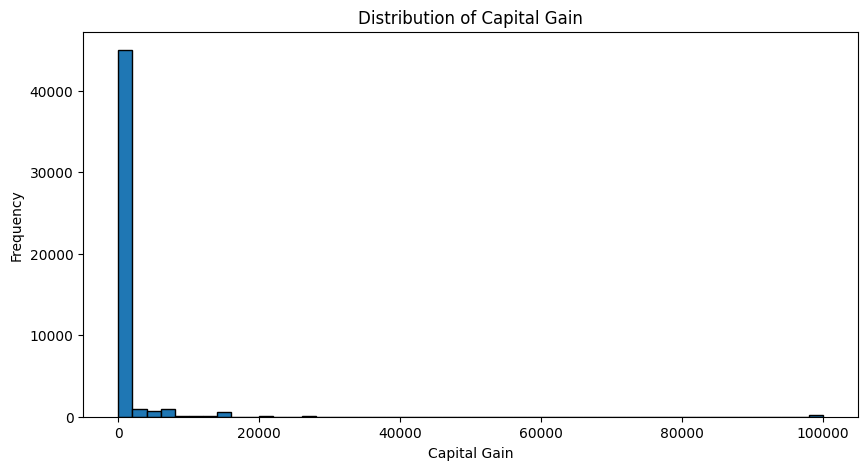

In [32]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["capital-gain"],
    bins=50,
    edgecolor="black"
)

plt.title("Distribution of Capital Gain")
plt.xlabel("Capital Gain")
plt.ylabel("Frequency")

plt.show()

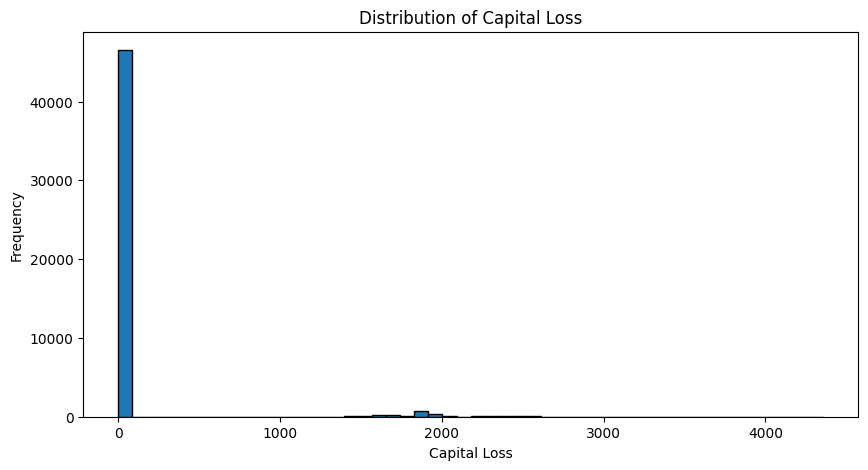

In [33]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["capital-loss"],
    bins=50,
    edgecolor="black"
)

plt.title("Distribution of Capital Loss")
plt.xlabel("Capital Loss")
plt.ylabel("Frequency")

plt.show()

In [34]:
correlation_matrix = df[numerical_columns].corr()

display(correlation_matrix.round(2))

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
age,1.00,-0.07,0.03,0.07,0.06,0.10
fnlwgt,-0.07,1.00,-0.04,-0.00,-0.00,-0.01
education-num,0.03,-0.04,1.00,0.13,0.08,0.14
capital-gain,0.07,-0.00,0.13,1.00,-0.03,0.08
capital-loss,0.06,-0.00,0.08,-0.03,1.00,0.05
hours-per-week,0.10,-0.01,0.14,0.08,0.05,1.00


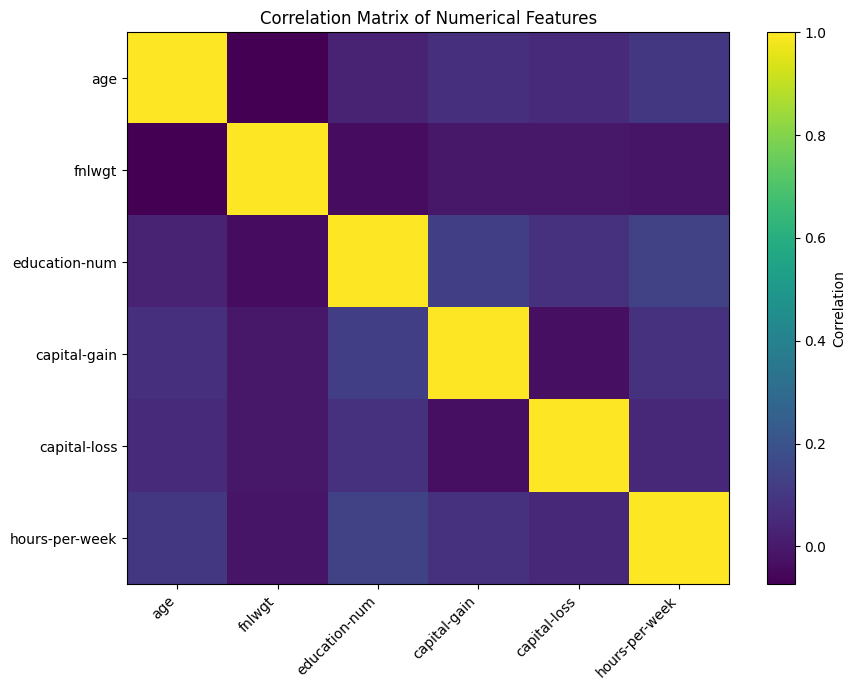

In [35]:
plt.figure(figsize=(9, 7))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar(
    label="Correlation"
)

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix of Numerical Features")

plt.tight_layout()

plt.show()

In [36]:
df_encoded = pd.get_dummies(
    df_clean,
    columns=categorical_columns,
    drop_first=False,
    dtype=int
)

print("Shape before encoding:", df_clean.shape)
print("Shape after encoding:", df_encoded.shape)

display(df_encoded.head())

Shape before encoding: (48826, 14)
Shape after encoding: (48826, 108)


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia,native-country_nan
0,39.0,77516,13.0,0,0,40.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,50.0,83311,13.0,0,0,32.5,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,38.0,215646,9.0,0,0,40.0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
3,53.0,234721,7.0,0,0,40.0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
4,28.0,338409,13.0,0,0,40.0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [37]:
print("Total columns after One-Hot Encoding:")
print(df_encoded.shape[1])

Total columns after One-Hot Encoding:
108


In [38]:
scaler = StandardScaler()

df_encoded[numerical_columns] = scaler.fit_transform(
    df_encoded[numerical_columns]
)

print("Numerical features successfully scaled.")

Numerical features successfully scaled.


In [39]:
display(
    df_encoded[numerical_columns].head()
)

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
0,0.035123,-1.146152,1.171344,0.0,0.0,-0.187370
1,0.864064,-1.085355,1.171344,0.0,0.0,-1.430414
2,-0.040236,0.303009,-0.456772,0.0,0.0,-0.187370
3,1.090139,0.503130,-1.270830,0.0,0.0,-0.187370
4,-0.793819,1.590950,1.171344,0.0,0.0,-0.187370


In [40]:
scaling_check = pd.DataFrame({
    "Mean": df_encoded[numerical_columns].mean(),
    "Standard Deviation":
        df_encoded[numerical_columns].std()
})

display(scaling_check.round(3))

,Mean,Standard Deviation
age,0.0,1.0
fnlwgt,0.0,1.0
education-num,0.0,1.0
capital-gain,0.0,0.0
capital-loss,0.0,0.0
hours-per-week,0.0,1.0


In [41]:
X = df_encoded.copy()

print("Final Cleaned Dataset Shape:")
print(X.shape)

display(X.head())

Final Cleaned Dataset Shape:
(48826, 108)


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia,native-country_nan
0,0.035123,-1.146152,1.171344,0.0,0.0,-0.187370,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,0.864064,-1.085355,1.171344,0.0,0.0,-1.430414,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,-0.040236,0.303009,-0.456772,0.0,0.0,-0.187370,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
3,1.090139,0.503130,-1.270830,0.0,0.0,-0.187370,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
4,-0.793819,1.590950,1.171344,0.0,0.0,-0.187370,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [42]:
print("Final Dataset Verification")
print("---------------------------")

print("Rows:", X.shape[0])
print("Columns:", X.shape[1])

print(
    "Missing Values:",
    X.isnull().sum().sum()
)

print(
    "Duplicate Rows:",
    X.duplicated().sum()
)

print(
    "Income Included:",
    "income" in X.columns
)

Final Dataset Verification
---------------------------
Rows: 48826
Columns: 108
Missing Values: 0
Duplicate Rows: 49
Income Included: False


In [43]:
X.to_csv(
    "cleaned_census_clustering_data.csv",
    index=False
)

print(
    "Cleaned dataset saved as "
    "cleaned_census_clustering_data.csv"
)

Cleaned dataset saved as cleaned_census_clustering_data.csv


In [44]:
# ============================================================
# EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (48826, 14)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,nan
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba


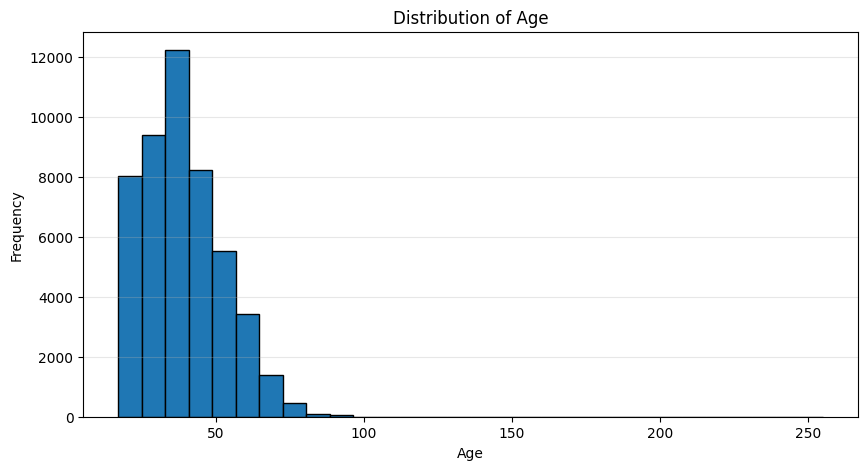

In [45]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["age"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.3)

plt.show()

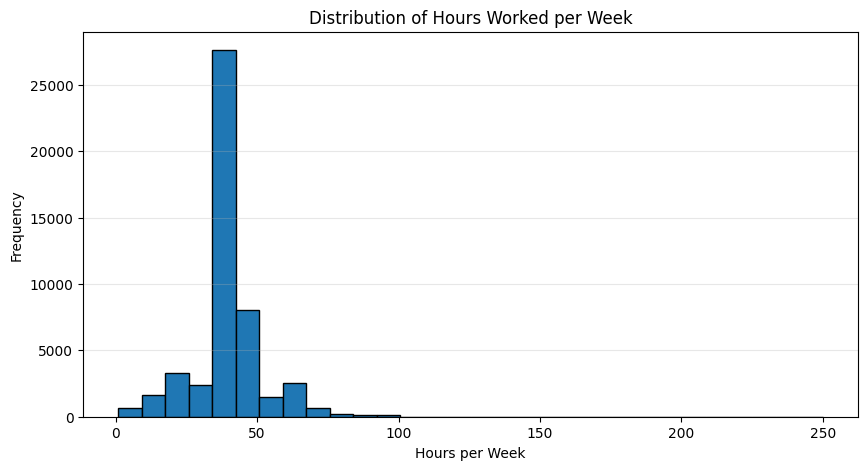

In [46]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["hours-per-week"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Hours Worked per Week")
plt.xlabel("Hours per Week")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.3)

plt.show()

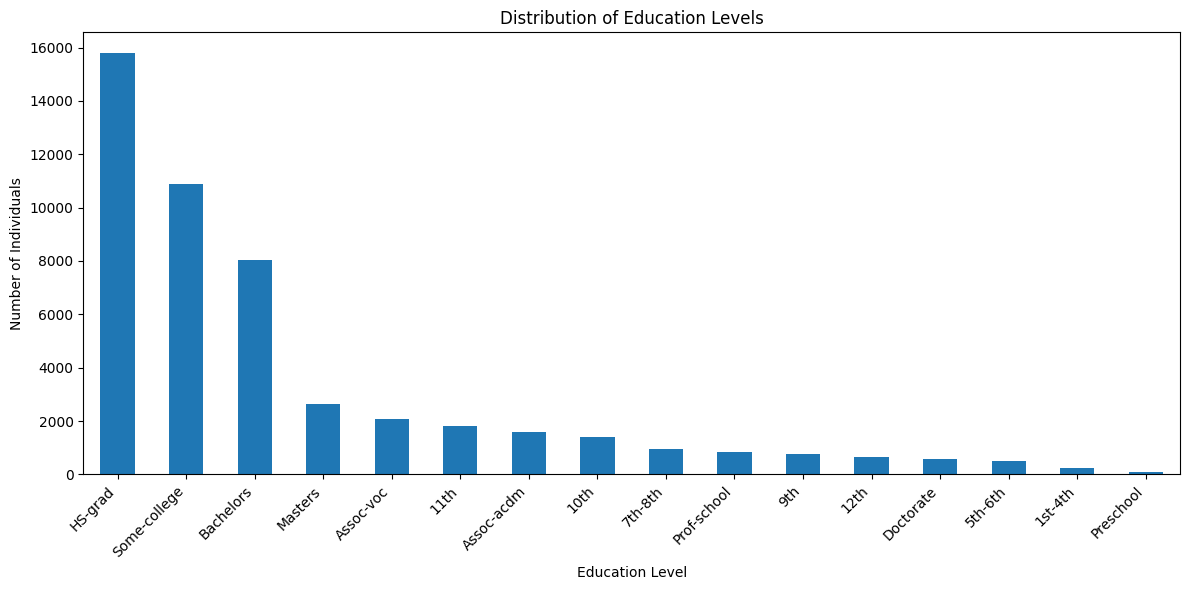

In [47]:
education_counts = df["education"].value_counts()

plt.figure(figsize=(12, 6))

education_counts.plot(kind="bar")

plt.title("Distribution of Education Levels")
plt.xlabel("Education Level")
plt.ylabel("Number of Individuals")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

In [48]:
education_table = education_counts.reset_index()

education_table.columns = [
    "Education Level",
    "Count"
]

display(education_table)

,Education Level,Count
0,HS-grad,15780
1,Some-college,10874
2,Bachelors,8021
3,Masters,2657
4,Assoc-voc,2060
5,11th,1812
6,Assoc-acdm,1601
7,10th,1389
8,7th-8th,955
9,Prof-school,834


In [49]:
capital_gain_skew = df["capital-gain"].skew()
capital_loss_skew = df["capital-loss"].skew()

print(
    "Capital Gain Skewness:",
    round(capital_gain_skew, 3)
)

print(
    "Capital Loss Skewness:",
    round(capital_loss_skew, 3)
)

Capital Gain Skewness: 11.893
Capital Loss Skewness: 4.569


In [50]:
def interpret_skewness(value):

    if value > 1:
        return "Highly positively/right skewed"

    elif value > 0.5:
        return "Moderately positively/right skewed"

    elif value < -1:
        return "Highly negatively/left skewed"

    elif value < -0.5:
        return "Moderately negatively/left skewed"

    else:
        return "Approximately symmetric"


print(
    "Capital Gain:",
    interpret_skewness(capital_gain_skew)
)

print(
    "Capital Loss:",
    interpret_skewness(capital_loss_skew)
)

Capital Gain: Highly positively/right skewed
Capital Loss: Highly positively/right skewed


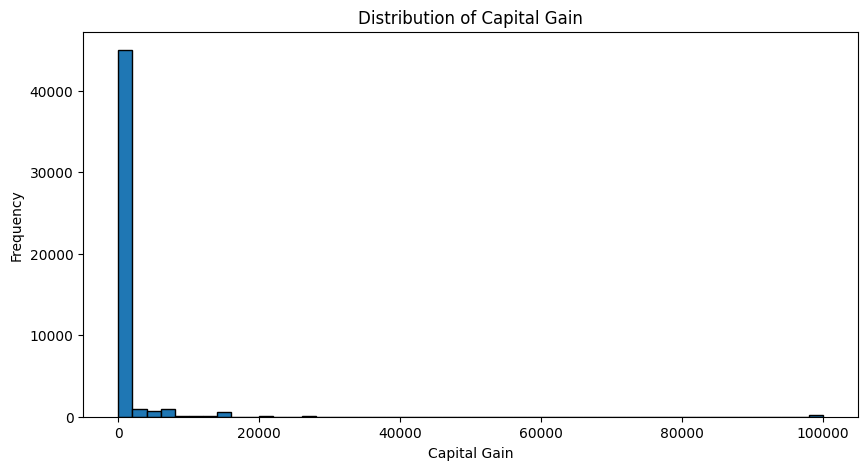

In [51]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["capital-gain"],
    bins=50,
    edgecolor="black"
)

plt.title("Distribution of Capital Gain")
plt.xlabel("Capital Gain")
plt.ylabel("Frequency")

plt.show()

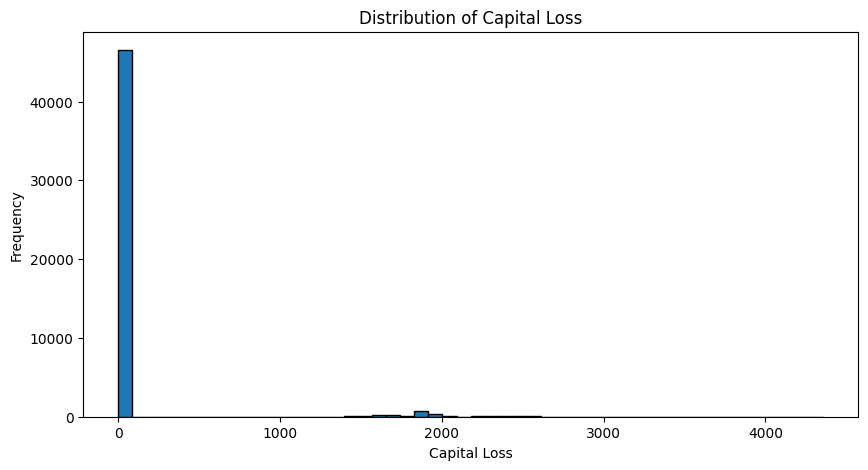

In [52]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["capital-loss"],
    bins=50,
    edgecolor="black"
)

plt.title("Distribution of Capital Loss")
plt.xlabel("Capital Loss")
plt.ylabel("Frequency")

plt.show()

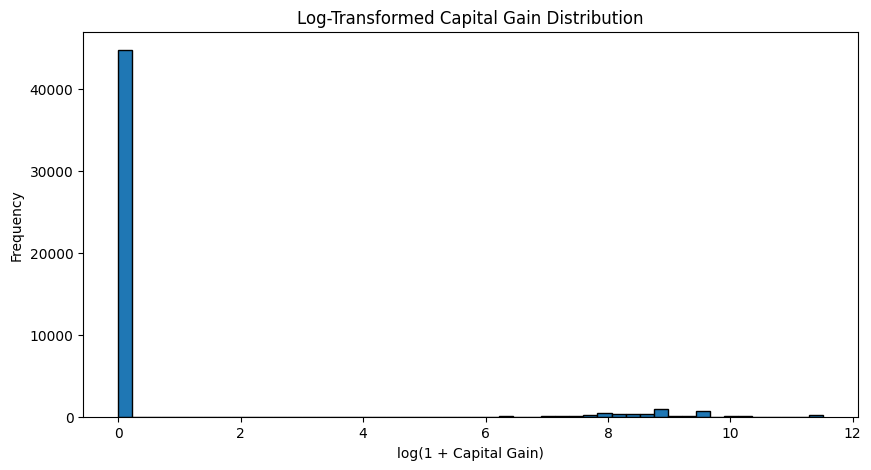

In [53]:
capital_gain_log = np.log1p(df["capital-gain"])

plt.figure(figsize=(10, 5))

plt.hist(
    capital_gain_log,
    bins=50,
    edgecolor="black"
)

plt.title("Log-Transformed Capital Gain Distribution")
plt.xlabel("log(1 + Capital Gain)")
plt.ylabel("Frequency")

plt.show()

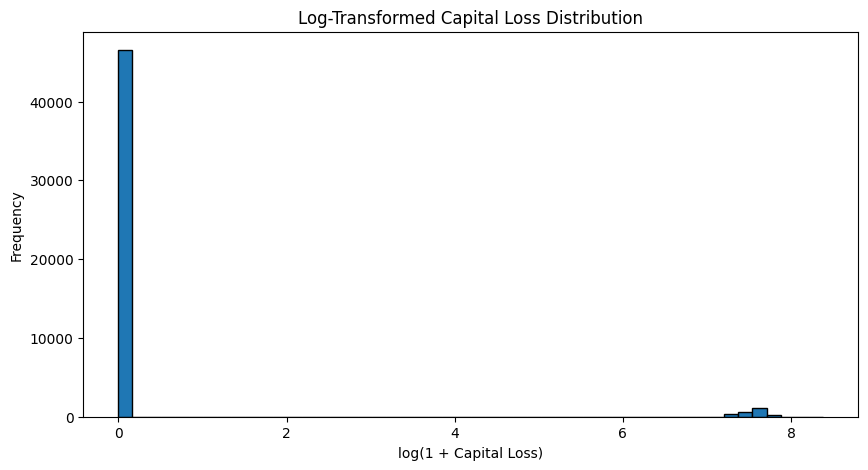

In [54]:
capital_loss_log = np.log1p(df["capital-loss"])

plt.figure(figsize=(10, 5))

plt.hist(
    capital_loss_log,
    bins=50,
    edgecolor="black"
)

plt.title("Log-Transformed Capital Loss Distribution")
plt.xlabel("log(1 + Capital Loss)")
plt.ylabel("Frequency")

plt.show()

In [55]:
numerical_columns = [
    "age",
    "fnlwgt",
    "education-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week"
]

correlation_matrix = df[
    numerical_columns
].corr()

display(correlation_matrix.round(3))

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
age,1.000,-0.074,0.029,0.074,0.056,0.099
fnlwgt,-0.074,1.000,-0.039,-0.004,-0.004,-0.011
education-num,0.029,-0.039,1.000,0.125,0.081,0.136
capital-gain,0.074,-0.004,0.125,1.000,-0.031,0.080
capital-loss,0.056,-0.004,0.081,-0.031,1.000,0.051
hours-per-week,0.099,-0.011,0.136,0.080,0.051,1.000


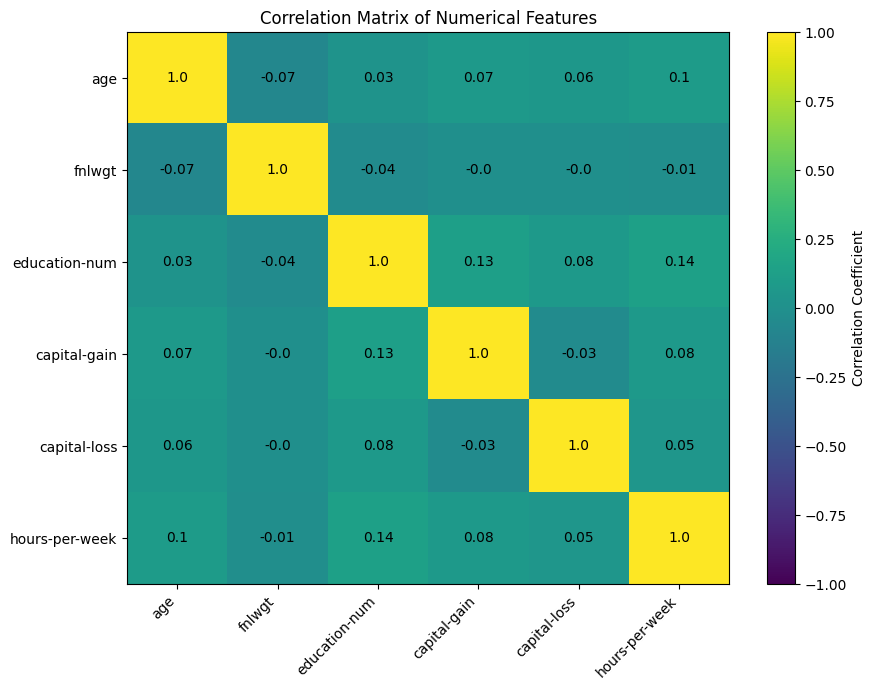

In [56]:
plt.figure(figsize=(9, 7))

plt.imshow(
    correlation_matrix,
    aspect="auto",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Correlation Coefficient")

plt.xticks(
    range(len(numerical_columns)),
    numerical_columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(numerical_columns)),
    numerical_columns
)

for i in range(len(numerical_columns)):
    for j in range(len(numerical_columns)):

        plt.text(
            j,
            i,
            round(
                correlation_matrix.iloc[i, j],
                2
            ),
            ha="center",
            va="center"
        )

plt.title("Correlation Matrix of Numerical Features")

plt.tight_layout()
plt.show()

In [57]:
print("Clustering Dataset Shape:")
print(X.shape)

display(X.head())

Clustering Dataset Shape:
(48826, 108)


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia,native-country_nan
0,0.035123,-1.146152,1.171344,0.0,0.0,-0.187370,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,0.864064,-1.085355,1.171344,0.0,0.0,-1.430414,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,-0.040236,0.303009,-0.456772,0.0,0.0,-0.187370,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
3,1.090139,0.503130,-1.270830,0.0,0.0,-0.187370,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
4,-0.793819,1.590950,1.171344,0.0,0.0,-0.187370,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [58]:
print(
    "Missing values:",
    X.isnull().sum().sum()
)

Missing values: 0


In [59]:
from sklearn.cluster import KMeans

inertia_values = []

k_values = range(2, 11)

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X)

    inertia_values.append(
        kmeans.inertia_
    )

    print(
        f"K = {k}, "
        f"Inertia = {kmeans.inertia_:.2f}"
    )

K = 2, Inertia = 368803.72
K = 3, Inertia = 337333.76
K = 4, Inertia = 318424.95
K = 5, Inertia = 302458.32
K = 6, Inertia = 290067.03
K = 7, Inertia = 279925.46
K = 8, Inertia = 272826.44
K = 9, Inertia = 266108.54
K = 10, Inertia = 261116.20


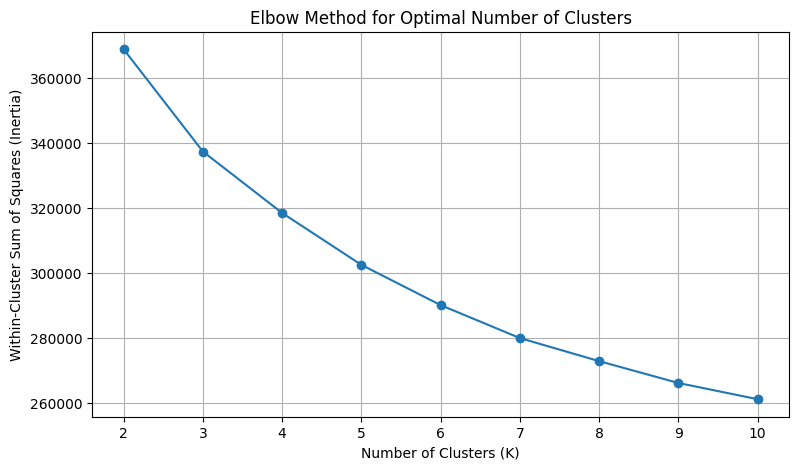

In [60]:
plt.figure(figsize=(9, 5))

plt.plot(
    list(k_values),
    inertia_values,
    marker="o"
)

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Within-Cluster Sum of Squares (Inertia)")

plt.xticks(list(k_values))
plt.grid(True)

plt.show()

In [61]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

sample_size = min(
    5000,
    len(X)
)

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    cluster_labels = kmeans.fit_predict(X)

    score = silhouette_score(
        X,
        cluster_labels,
        sample_size=sample_size,
        random_state=42
    )

    silhouette_scores.append(score)

    print(
        f"K = {k}: "
        f"Silhouette Score = {score:.4f}"
    )

K = 2: Silhouette Score = 0.1170
K = 3: Silhouette Score = 0.1113
K = 4: Silhouette Score = 0.1046
K = 5: Silhouette Score = 0.1001
K = 6: Silhouette Score = 0.1011
K = 7: Silhouette Score = 0.1069
K = 8: Silhouette Score = 0.1030
K = 9: Silhouette Score = 0.0949
K = 10: Silhouette Score = 0.0925


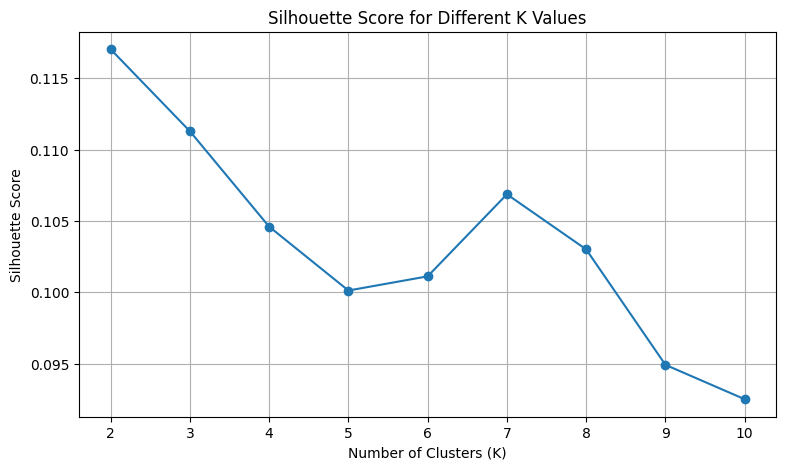

In [62]:
plt.figure(figsize=(9, 5))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Score for Different K Values")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.xticks(range(2, 11))
plt.grid(True)

plt.show()

In [63]:
best_k = list(
    range(2, 11)
)[
    np.argmax(silhouette_scores)
]

best_score = max(
    silhouette_scores
)

print(
    "Best K based on Silhouette Score:",
    best_k
)

print(
    "Best Silhouette Score:",
    round(best_score, 4)
)

Best K based on Silhouette Score: 2
Best Silhouette Score: 0.117


In [64]:
final_kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

kmeans_labels = final_kmeans.fit_predict(X)

In [65]:
X_kmeans = X.copy()

X_kmeans["KMeans_Cluster"] = (
    kmeans_labels
)

display(X_kmeans.head())

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia,native-country_nan,KMeans_Cluster
0,0.035123,-1.146152,1.171344,0.0,0.0,-0.187370,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
1,0.864064,-1.085355,1.171344,0.0,0.0,-1.430414,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
2,-0.040236,0.303009,-0.456772,0.0,0.0,-0.187370,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
3,1.090139,0.503130,-1.270830,0.0,0.0,-0.187370,0,0,0,1,...,0,0,0,0,0,1,0,0,0,1
4,-0.793819,1.590950,1.171344,0.0,0.0,-0.187370,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [66]:
kmeans_cluster_counts = pd.Series(
    kmeans_labels
).value_counts().sort_index()

print("K-Means Cluster Distribution:")

display(
    kmeans_cluster_counts.to_frame(
        name="Number of Individuals"
    )
)

K-Means Cluster Distribution:


,Number of Individuals
0,22971
1,25855


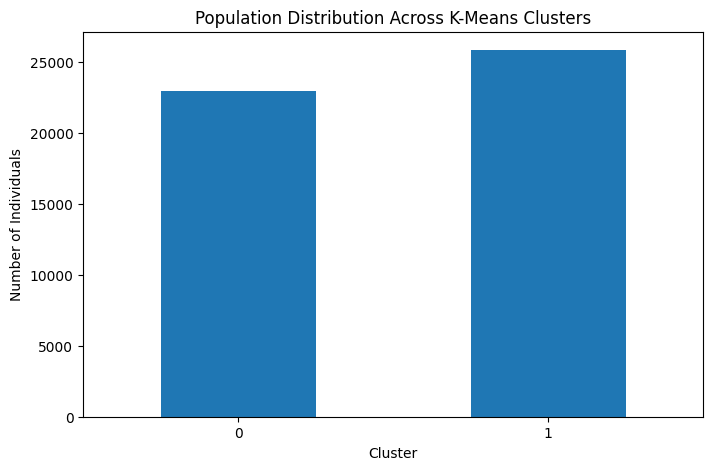

In [67]:
plt.figure(figsize=(8, 5))

kmeans_cluster_counts.plot(
    kind="bar"
)

plt.title("Population Distribution Across K-Means Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of Individuals")

plt.xticks(rotation=0)

plt.show()

In [68]:
df_kmeans = df.copy()

df_kmeans["KMeans_Cluster"] = (
    kmeans_labels
)

display(df_kmeans.head())

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,KMeans_Cluster
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,nan,1
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,1
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,0
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,1
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,0


In [69]:
kmeans_profile = (
    df_kmeans
    .groupby("KMeans_Cluster")[
        [
            "age",
            "education-num",
            "capital-gain",
            "capital-loss",
            "hours-per-week"
        ]
    ]
    .mean()
    .round(2)
)

display(kmeans_profile)

,age,education-num,capital-gain,capital-loss,hours-per-week
KMeans_Cluster,,,,,
0,30.75,9.49,303.50,51.21,35.57
1,45.57,10.60,1768.79,119.80,44.75


In [70]:
occupation_profile = (
    df_kmeans
    .groupby("KMeans_Cluster")["occupation"]
    .agg(
        lambda x:
        x.mode()[0]
        if not x.mode().empty
        else np.nan
    )
)

display(
    occupation_profile.to_frame(
        name="Most Common Occupation"
    )
)

,Most Common Occupation
KMeans_Cluster,
0,Adm-clerical
1,Exec-managerial


In [71]:
education_profile = (
    df_kmeans
    .groupby("KMeans_Cluster")["education"]
    .agg(
        lambda x:
        x.mode()[0]
        if not x.mode().empty
        else np.nan
    )
)

display(
    education_profile.to_frame(
        name="Most Common Education"
    )
)

,Most Common Education
KMeans_Cluster,
0,HS-grad
1,HS-grad


In [72]:
workclass_profile = (
    df_kmeans
    .groupby("KMeans_Cluster")["workclass"]
    .agg(
        lambda x:
        x.mode()[0]
        if not x.mode().empty
        else np.nan
    )
)

display(
    workclass_profile.to_frame(
        name="Most Common Workclass"
    )
)

,Most Common Workclass
KMeans_Cluster,
0,Private
1,Private


In [73]:
cluster_summary = pd.DataFrame({
    "Population":
        df_kmeans
        .groupby("KMeans_Cluster")
        .size(),

    "Average Age":
        df_kmeans
        .groupby("KMeans_Cluster")["age"]
        .mean(),

    "Average Education Num":
        df_kmeans
        .groupby("KMeans_Cluster")["education-num"]
        .mean(),

    "Average Hours/Week":
        df_kmeans
        .groupby("KMeans_Cluster")["hours-per-week"]
        .mean(),

    "Most Common Education":
        education_profile,

    "Most Common Occupation":
        occupation_profile,

    "Most Common Workclass":
        workclass_profile
})

display(
    cluster_summary.round(2)
)

,Population,Average Age,Average Education Num,Average Hours/Week,Most Common Education,Most Common Occupation,Most Common Workclass
KMeans_Cluster,,,,,,,
0,22971,30.75,9.49,35.57,HS-grad,Adm-clerical,Private
1,25855,45.57,10.60,44.75,HS-grad,Exec-managerial,Private


In [74]:
ag_sample_size = min(
    5000,
    len(X)
)

X_ag = X.sample(
    n=ag_sample_size,
    random_state=42
)

print(
    "Agglomerative clustering sample size:",
    X_ag.shape
)

Agglomerative clustering sample size: (5000, 108)


In [76]:
from scipy.cluster.hierarchy import (
    linkage,
    dendrogram
)

dendrogram_sample_size = min(
    1000,
    len(X)
)

X_dendro = X.sample(
    n=dendrogram_sample_size,
    random_state=42
)

linked = linkage(
    X_dendro,
    method="ward"
)

In [77]:
from scipy.cluster.hierarchy import (
    linkage,
    dendrogram
)

dendrogram_sample_size = min(
    1000,
    len(X)
)

X_dendro = X.sample(
    n=dendrogram_sample_size,
    random_state=42
)

linked = linkage(
    X_dendro,
    method="ward"
)

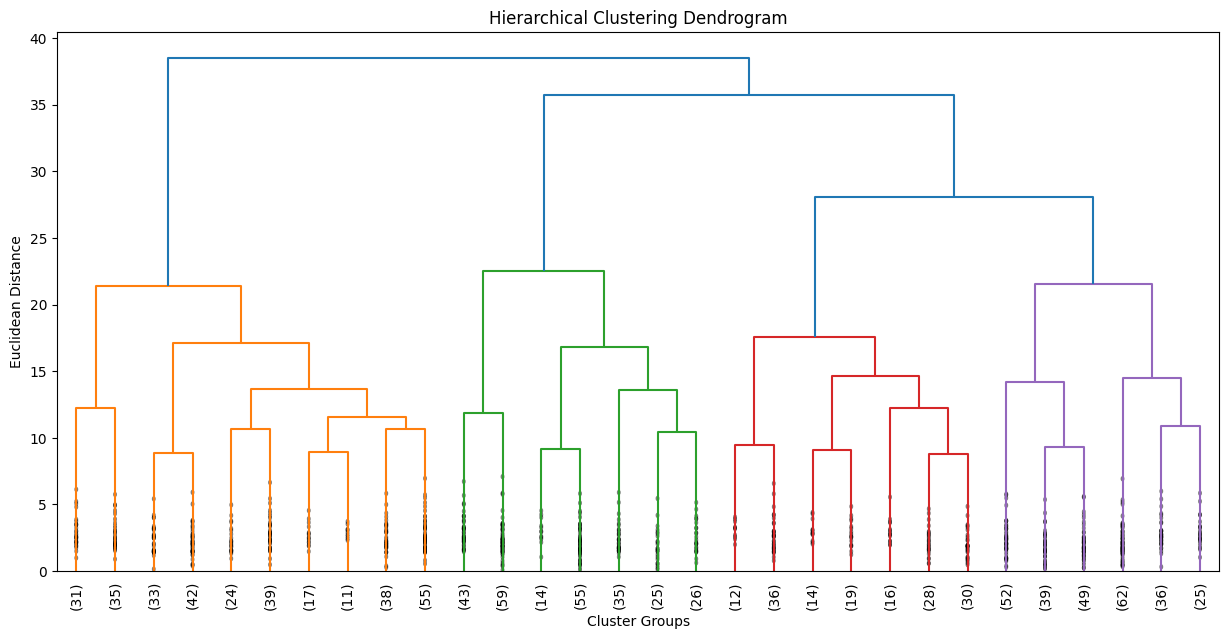

In [78]:
plt.figure(figsize=(15, 7))

dendrogram(
    linked,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Cluster Groups")
plt.ylabel("Euclidean Distance")

plt.show()

In [79]:
from sklearn.cluster import (
    AgglomerativeClustering
)

agg_model = AgglomerativeClustering(
    n_clusters=best_k,
    linkage="ward"
)

agg_labels = agg_model.fit_predict(
    X_ag
)

print(
    "Agglomerative clustering completed."
)

Agglomerative clustering completed.


In [80]:
agg_counts = pd.Series(
    agg_labels
).value_counts().sort_index()

display(
    agg_counts.to_frame(
        name="Number of Individuals"
    )
)

,Number of Individuals
0,3602
1,1398


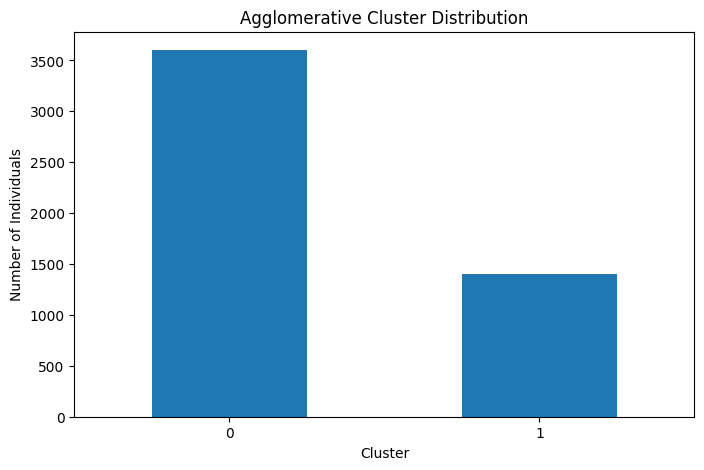

In [81]:
plt.figure(figsize=(8, 5))

agg_counts.plot(
    kind="bar"
)

plt.title(
    "Agglomerative Cluster Distribution"
)

plt.xlabel("Cluster")
plt.ylabel("Number of Individuals")

plt.xticks(rotation=0)

plt.show()

In [82]:
kmeans_sample_labels = (
    final_kmeans.predict(X_ag)
)

In [83]:
comparison_df = pd.DataFrame({
    "KMeans": kmeans_sample_labels,
    "Agglomerative": agg_labels
})

comparison_table = pd.crosstab(
    comparison_df["KMeans"],
    comparison_df["Agglomerative"]
)

display(comparison_table)

Agglomerative,0,1
KMeans,,
0,2197,137
1,1405,1261


In [84]:
from sklearn.metrics import adjusted_rand_score

ari_score = adjusted_rand_score(
    kmeans_sample_labels,
    agg_labels
)

print(
    "Adjusted Rand Index:",
    round(ari_score, 4)
)

Adjusted Rand Index: 0.146


In [85]:
agg_silhouette = silhouette_score(
    X_ag,
    agg_labels,
    sample_size=min(
        3000,
        len(X_ag)
    ),
    random_state=42
)

print(
    "Agglomerative Silhouette Score:",
    round(agg_silhouette, 4)
)

Agglomerative Silhouette Score: 0.0934


In [86]:
print(
    "K-Means Best Silhouette Score:",
    round(best_score, 4)
)

print(
    "Agglomerative Silhouette Score:",
    round(agg_silhouette, 4)
)

K-Means Best Silhouette Score: 0.117
Agglomerative Silhouette Score: 0.0934


In [87]:
model_comparison = pd.DataFrame({
    "Algorithm": [
        "K-Means",
        "Agglomerative"
    ],

    "Number of Clusters": [
        best_k,
        best_k
    ],

    "Silhouette Score": [
        best_score,
        agg_silhouette
    ]
})

display(
    model_comparison.round(4)
)

,Algorithm,Number of Clusters,Silhouette Score
0,K-Means,2,0.1170
1,Agglomerative,2,0.0934


In [88]:
from sklearn.cluster import DBSCAN

X_dbscan = X.sample(
    n=min(5000, len(X)),
    random_state=42
)

dbscan = DBSCAN(
    eps=3.0,
    min_samples=10
)

dbscan_labels = dbscan.fit_predict(
    X_dbscan
)

In [89]:
unique_labels, counts = np.unique(
    dbscan_labels,
    return_counts=True
)

dbscan_summary = pd.DataFrame({
    "Cluster": unique_labels,
    "Number of Points": counts
})

display(dbscan_summary)

,Cluster,Number of Points
0,-1,6
1,0,4994


In [90]:
n_clusters_dbscan = len(
    set(dbscan_labels)
) - (
    1 if -1 in dbscan_labels else 0
)

n_noise = list(
    dbscan_labels
).count(-1)

print(
    "Number of DBSCAN clusters:",
    n_clusters_dbscan
)

print(
    "Number of noise points:",
    n_noise
)

print(
    "Percentage of noise:",
    round(
        n_noise /
        len(dbscan_labels) * 100,
        2
    ),
    "%"
)

Number of DBSCAN clusters: 1
Number of noise points: 6
Percentage of noise: 0.12 %


In [91]:
valid_mask = (
    dbscan_labels != -1
)

valid_labels = (
    dbscan_labels[valid_mask]
)

if len(set(valid_labels)) >= 2:

    dbscan_silhouette = silhouette_score(
        X_dbscan.iloc[
            np.where(valid_mask)[0]
        ],
        valid_labels
    )

    print(
        "DBSCAN Silhouette Score:",
        round(
            dbscan_silhouette,
            4
        )
    )

else:

    print(
        "DBSCAN did not identify enough "
        "clusters for Silhouette Score."
    )

DBSCAN did not identify enough clusters for Silhouette Score.


In [92]:
silhouette_table = pd.DataFrame({
    "K": range(2, 11),
    "Silhouette Score":
        silhouette_scores
})

display(
    silhouette_table.round(4)
)

,K,Silhouette Score
0,2,0.1170
1,3,0.1113
2,4,0.1046
3,5,0.1001
4,6,0.1011
5,7,0.1069
6,8,0.1030
7,9,0.0949
8,10,0.0925


In [93]:
print("=" * 50)

print(
    "OPTIMAL NUMBER OF CLUSTERS"
)

print("=" * 50)

print(
    "Best K:",
    best_k
)

print(
    "Silhouette Score:",
    round(best_score, 4)
)

OPTIMAL NUMBER OF CLUSTERS
Best K: 2
Silhouette Score: 0.117


In [94]:
clustered_dataset = df.copy()

clustered_dataset[
    "KMeans_Cluster"
] = kmeans_labels

clustered_dataset.to_csv(
    "census_workforce_clusters.csv",
    index=False
)

print(
    "Clustered dataset saved successfully."
)

Clustered dataset saved successfully.


In [95]:
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [96]:
# ============================================
# PCA - DIMENSIONALITY REDUCTION
# ============================================

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

print("Original Dataset Shape:", X.shape)
print("PCA Dataset Shape:", X_pca.shape)

Original Dataset Shape: (48826, 108)
PCA Dataset Shape: (48826, 2)


In [97]:
pca_df = pd.DataFrame(
    X_pca,
    columns=[
        "Principal Component 1",
        "Principal Component 2"
    ]
)

display(pca_df.head())

,Principal Component 1,Principal Component 2
0,0.411138,1.003770
1,1.056147,-0.162838
2,-0.478704,-0.394041
3,0.218049,-1.722701
4,-0.271234,1.671375


In [98]:
explained_variance = pca.explained_variance_ratio_

print(
    "Explained Variance Ratio of PC1:",
    round(explained_variance[0], 4)
)

print(
    "Explained Variance Ratio of PC2:",
    round(explained_variance[1], 4)
)

Explained Variance Ratio of PC1: 0.1765
Explained Variance Ratio of PC2: 0.1297


In [99]:
total_variance = explained_variance.sum()

print(
    "Total Variance Explained by First Two Principal Components:",
    round(total_variance, 4)
)

print(
    "Percentage of Variance Explained:",
    round(total_variance * 100, 2),
    "%"
)

Total Variance Explained by First Two Principal Components: 0.3062
Percentage of Variance Explained: 30.62 %


In [100]:
variance_table = pd.DataFrame({
    "Principal Component": [
        "PC1",
        "PC2"
    ],
    "Explained Variance Ratio": [
        explained_variance[0],
        explained_variance[1]
    ],
    "Explained Variance (%)": [
        explained_variance[0] * 100,
        explained_variance[1] * 100
    ]
})

display(
    variance_table.round(4)
)

,Principal Component,Explained Variance Ratio,Explained Variance (%)
0,PC1,0.1765,17.6522
1,PC2,0.1297,12.9717


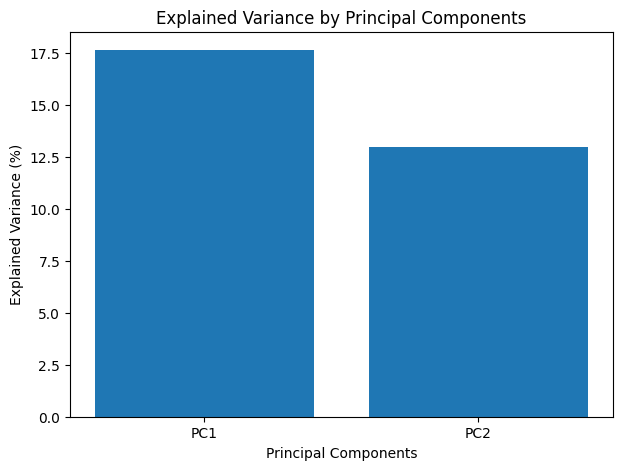

In [101]:
plt.figure(figsize=(7, 5))

plt.bar(
    ["PC1", "PC2"],
    explained_variance * 100
)

plt.title(
    "Explained Variance by Principal Components"
)

plt.xlabel(
    "Principal Components"
)

plt.ylabel(
    "Explained Variance (%)"
)

plt.show()

In [102]:
kmeans_labels
pca_df["KMeans_Cluster"] = kmeans_labels

display(pca_df.head())

,Principal Component 1,Principal Component 2,KMeans_Cluster
0,0.411138,1.003770,1
1,1.056147,-0.162838,1
2,-0.478704,-0.394041,0
3,0.218049,-1.722701,1
4,-0.271234,1.671375,0


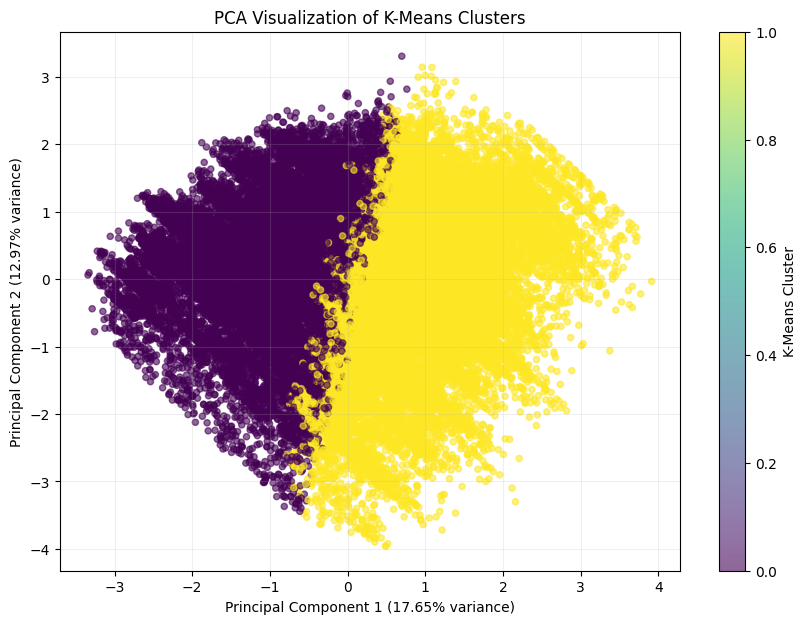

In [103]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    pca_df["Principal Component 1"],
    pca_df["Principal Component 2"],
    c=pca_df["KMeans_Cluster"],
    cmap="viridis",
    alpha=0.6,
    s=20
)

plt.title(
    "PCA Visualization of K-Means Clusters"
)

plt.xlabel(
    f"Principal Component 1 "
    f"({explained_variance[0] * 100:.2f}% variance)"
)

plt.ylabel(
    f"Principal Component 2 "
    f"({explained_variance[1] * 100:.2f}% variance)"
)

plt.colorbar(
    scatter,
    label="K-Means Cluster"
)

plt.grid(alpha=0.2)

plt.show()

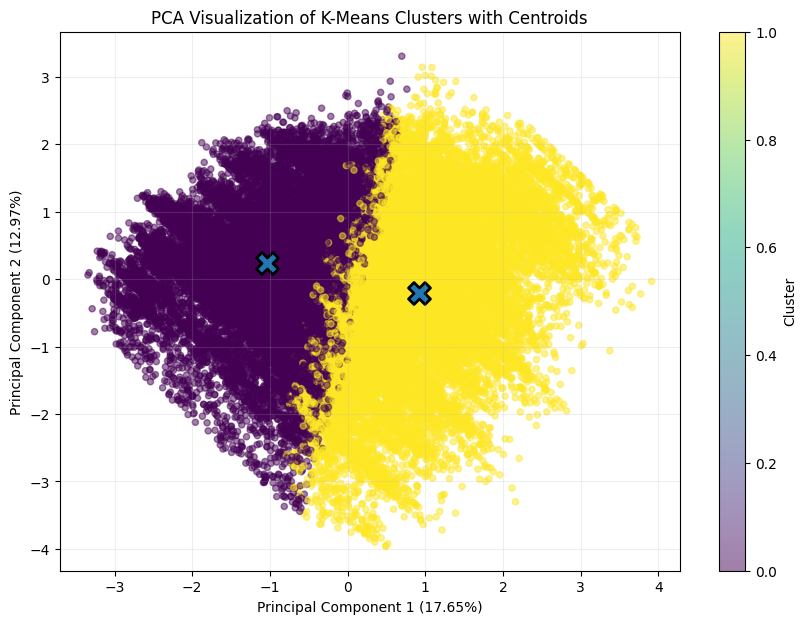

In [104]:
centers_pca = pca.transform(
    final_kmeans.cluster_centers_
)

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels,
    cmap="viridis",
    alpha=0.5,
    s=20
)

plt.scatter(
    centers_pca[:, 0],
    centers_pca[:, 1],
    marker="X",
    s=250,
    edgecolor="black",
    linewidth=2
)

plt.title(
    "PCA Visualization of K-Means Clusters with Centroids"
)

plt.xlabel(
    f"Principal Component 1 "
    f"({explained_variance[0] * 100:.2f}%)"
)

plt.ylabel(
    f"Principal Component 2 "
    f"({explained_variance[1] * 100:.2f}%)"
)

plt.colorbar(
    scatter,
    label="Cluster"
)

plt.grid(alpha=0.2)

plt.show()

In [105]:
X_ag
X_ag_pca = pca.transform(X_ag)

agg_pca_df = pd.DataFrame(
    X_ag_pca,
    columns=[
        "Principal Component 1",
        "Principal Component 2"
    ],
    index=X_ag.index
)

agg_pca_df["Agglomerative_Cluster"] = (
    agg_labels
)

display(agg_pca_df.head())

,Principal Component 1,Principal Component 2,Agglomerative_Cluster
26233,0.163209,-0.663205,0
14222,1.039510,-0.457940,1
1122,0.329781,-0.332056,0
12790,0.637056,1.017982,1
12290,1.744941,-0.739702,1


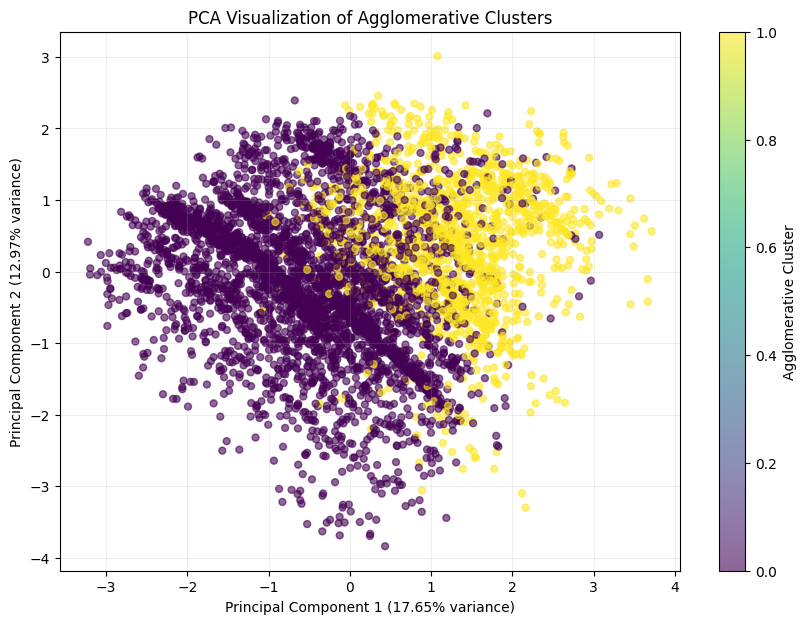

In [106]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    agg_pca_df["Principal Component 1"],
    agg_pca_df["Principal Component 2"],
    c=agg_pca_df[
        "Agglomerative_Cluster"
    ],
    cmap="viridis",
    alpha=0.6,
    s=25
)

plt.title(
    "PCA Visualization of Agglomerative Clusters"
)

plt.xlabel(
    f"Principal Component 1 "
    f"({explained_variance[0] * 100:.2f}% variance)"
)

plt.ylabel(
    f"Principal Component 2 "
    f"({explained_variance[1] * 100:.2f}% variance)"
)

plt.colorbar(
    scatter,
    label="Agglomerative Cluster"
)

plt.grid(alpha=0.2)

plt.show()

In [107]:
kmeans_ag_labels = final_kmeans.predict(
    X_ag
)

In [108]:
comparison_pca_df = pd.DataFrame(
    X_ag_pca,
    columns=[
        "PC1",
        "PC2"
    ]
)

comparison_pca_df[
    "KMeans"
] = kmeans_ag_labels

comparison_pca_df[
    "Agglomerative"
] = agg_labels

display(comparison_pca_df.head())

,PC1,PC2,KMeans,Agglomerative
0,0.163209,-0.663205,1,0
1,1.039510,-0.457940,1,1
2,0.329781,-0.332056,1,0
3,0.637056,1.017982,1,1
4,1.744941,-0.739702,1,1


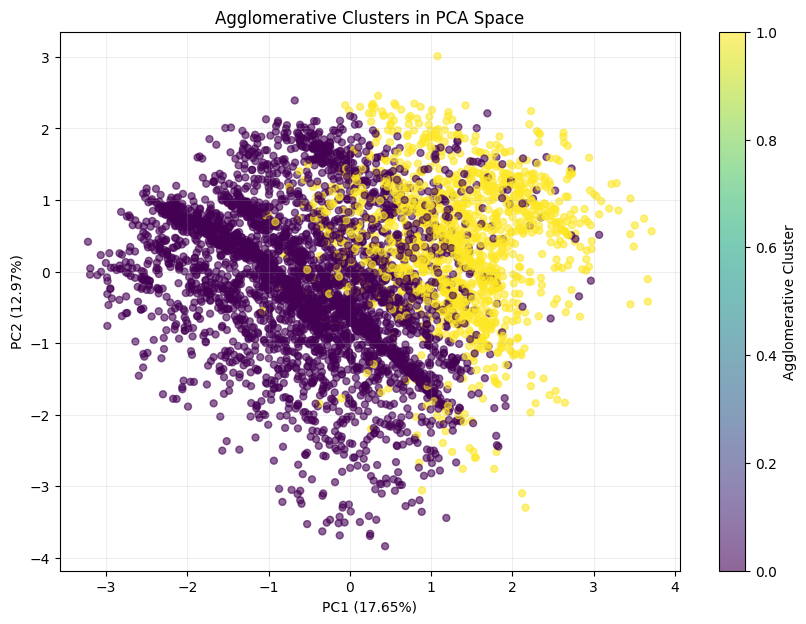

In [109]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    comparison_pca_df["PC1"],
    comparison_pca_df["PC2"],
    c=comparison_pca_df[
        "Agglomerative"
    ],
    cmap="viridis",
    alpha=0.6,
    s=25
)

plt.title(
    "Agglomerative Clusters in PCA Space"
)

plt.xlabel(
    f"PC1 ({explained_variance[0] * 100:.2f}%)"
)

plt.ylabel(
    f"PC2 ({explained_variance[1] * 100:.2f}%)"
)

plt.colorbar(
    scatter,
    label="Agglomerative Cluster"
)

plt.grid(alpha=0.2)

plt.show()

In [110]:
variance_percentage = (
    total_variance * 100
)

print(
    f"The first two principal components "
    f"capture {variance_percentage:.2f}% "
    f"of the total variance."
)

if variance_percentage >= 70:

    print(
        "Interpretation: PC1 and PC2 retain a "
        "large proportion of the dataset information."
    )

elif variance_percentage >= 40:

    print(
        "Interpretation: PC1 and PC2 retain a "
        "moderate proportion of the dataset information."
    )

else:

    print(
        "Interpretation: PC1 and PC2 retain a relatively "
        "small proportion of the total information. "
        "The 2D PCA plot is therefore mainly useful "
        "for visualization."
    )

The first two principal components capture 30.62% of the total variance.
Interpretation: PC1 and PC2 retain a relatively small proportion of the total information. The 2D PCA plot is therefore mainly useful for visualization.


In [111]:
pca_full = PCA()

pca_full.fit(X)

cumulative_variance = np.cumsum(
    pca_full.explained_variance_ratio_
)

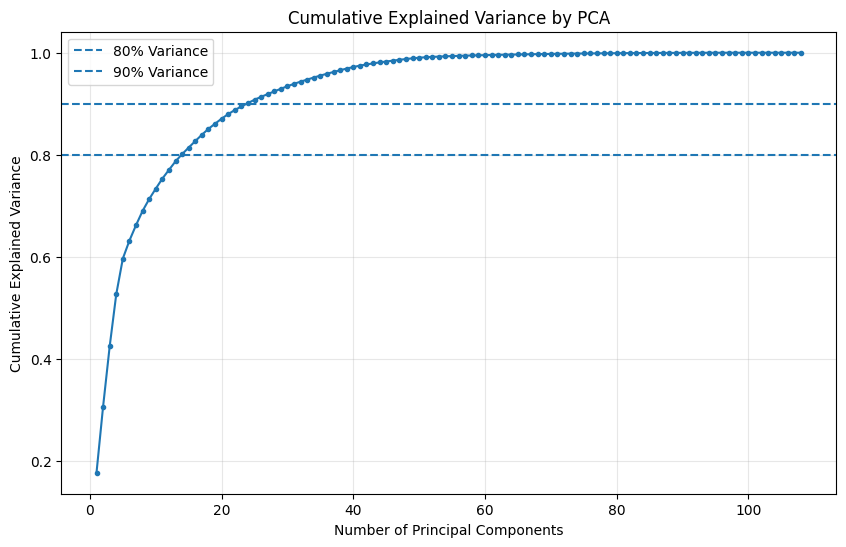

In [112]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(
        1,
        len(cumulative_variance) + 1
    ),
    cumulative_variance,
    marker="o",
    markersize=3
)

plt.axhline(
    y=0.80,
    linestyle="--",
    label="80% Variance"
)

plt.axhline(
    y=0.90,
    linestyle="--",
    label="90% Variance"
)

plt.title(
    "Cumulative Explained Variance by PCA"
)

plt.xlabel(
    "Number of Principal Components"
)

plt.ylabel(
    "Cumulative Explained Variance"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [113]:
pca_output = pca_df.copy()

pca_output.to_csv(
    "census_pca_kmeans_results.csv",
    index=False
)

print(
    "PCA results saved successfully."
)

PCA results saved successfully.
